# Interpreting GPT-2 with a Sparse Autoencoder

In the last lecture, we built a TopK sparse autoencoder and trained it on sentence embeddings. In this activity, we'll apply the exact same machinery to something much more interesting: the *internal* activations of a real language model.

The question we're asking is: **what features does GPT-2 learn at a given layer, and can we read them out?**

The plan:
1. Run some text through GPT-2 and capture the residual stream at one layer
2. Train a TopK SAE on those activations
3. Poke around the learned features by looking at which *tokens* activate them most strongly

Everything is set up to run on CPU. The SAE is small and the corpus is tiny, so training should finish in a couple of minutes on a laptop.

In [1]:
from collections import namedtuple
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from tqdm.notebook import tqdm
from datasets import load_dataset
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

DEVICE = "cpu"

## Load GPT-2 and a small text corpus

We'll use GPT-2 small (124M parameters) — plenty of internal structure to explore, and small enough to run on CPU. For our text corpus, we'll use a slice of [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories), a collection of simple short stories written at a grade-school reading level. The vocabulary is narrow and the sentence structures are repetitive, which tends to produce surprisingly clean, human-readable features.

In [2]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()
model.to(DEVICE)

print(f"Model loaded on {DEVICE}. Hidden size: {model.config.n_embd}. Layers: {model.config.n_layer}.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cpu. Hidden size: 768. Layers: 12.


In [3]:
stories = load_dataset("roneneldan/TinyStories", split="train[:1000]")
texts = [s["text"] for s in stories]
print(f"{len(texts)} stories loaded. Example:\n")
print(texts[0])

1000 stories loaded. Example:

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


We tokenize every story to a fixed length of 64 tokens. Shorter stories are padded; longer ones are truncated. We'll use the attention mask later to throw away the padding positions before training the SAE.

In [4]:
SEQ_LEN = 64

enc = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=SEQ_LEN,
    return_tensors="pt",
)
print(f"input_ids shape: {enc.input_ids.shape}")
print(f"Real (non-padding) tokens: {enc.attention_mask.sum().item()}")

input_ids shape: torch.Size([1000, 64])
Real (non-padding) tokens: 64000


## Capturing residual stream activations

The **residual stream** is the sequence of hidden states that flows through a transformer. Each attention block and each MLP block *adds* its output back into this stream. If we want to see what the model "knows" at a given point in its computation, the residual stream is the natural place to look.

We grab it with a **forward hook**: a small function that PyTorch calls every time a particular module runs. We attach a hook to the output of a transformer block, run some text through the model, and stash the output tensors as they fly by.

Pick a layer. The default below is layer 6 (out of 12), roughly the middle of the model. Features at the middle tend to be richer than at the edges — early layers pick up surface patterns (specific tokens, common bigrams), and late layers are preparing to predict the next token. You're encouraged to try different layers later and see how features change.

In [5]:
LAYER = 6

captured = []

def hook(module, inputs, output):
    # GPT-2 blocks return a tuple; the first element is the residual stream output.
    hidden = output[0] if isinstance(output, tuple) else output
    captured.append(hidden.detach().cpu())

handle = model.transformer.h[LAYER].register_forward_hook(hook)

Now we run the tokenized stories through GPT-2 in small batches. We don't need the output logits — we just need the hook to fire. Remember to remove the hook afterwards so it doesn't keep firing on future forward passes.

In [6]:
BATCH_SIZE = 16

with torch.no_grad():
    for i in tqdm(range(0, len(enc.input_ids), BATCH_SIZE)):
        model(
            input_ids=enc.input_ids[i : i + BATCH_SIZE].to(DEVICE),
            attention_mask=enc.attention_mask[i : i + BATCH_SIZE].to(DEVICE),
        )

handle.remove()
activations = torch.cat(captured, dim=0)  # [N, SEQ_LEN, 768]
captured.clear()
print(f"Activations shape: {activations.shape}")

  0%|          | 0/63 [00:00<?, ?it/s]

Activations shape: torch.Size([1000, 64, 768])


Each story gives us 64 activation vectors, but many of those positions are padding. We flatten to a 2D tensor of shape `(num_tokens, 768)` and keep only the real (non-padding) rows.

We also keep a parallel record of which `(doc_idx, token_idx)` each row came from, so that later we can reconstruct the context around any activation.

In [7]:
N, T = enc.input_ids.shape
mask = enc.attention_mask.bool()

doc_grid, tok_grid = torch.meshgrid(torch.arange(N), torch.arange(T), indexing="ij")
doc_indices = doc_grid[mask]
tok_indices = tok_grid[mask]

X = activations[mask]  # [num_real_tokens, 768]
print(f"X shape: {X.shape}")

X shape: torch.Size([64000, 768])


## Train the SAE

We reuse the TopK SAE, auxiliary loss, and training loop from Lecture 10 verbatim. The only thing that changes is the data — instead of sentence embeddings, we're feeding in GPT-2's residual stream.

In [8]:
SAEOutput = namedtuple("SAEOutput", ["x_hat", "h_sparse", "h"])


class TopKSAE(nn.Module):
    def __init__(self, embed_dim: int, expansion_factor: float, k: int):
        super().__init__()
        self.k = k
        self.h_dim = int(embed_dim * expansion_factor)
        self.encoder = nn.Linear(embed_dim, self.h_dim)
        self.decoder = nn.Linear(self.h_dim, embed_dim)

    def forward(self, x: Tensor) -> SAEOutput:
        h = self.encoder(x)
        topk, _ = torch.topk(h, self.k, dim=1)
        m = h >= topk[:, [-1]]
        h_sparse = h * m.float()
        x_hat = self.decoder(h_sparse)
        return SAEOutput(x_hat, h_sparse, h)

In [9]:
SAELossOutput = namedtuple("SAELossOutput", ["total_loss", "mse_loss", "aux_loss"])


class TopKSAELoss(nn.Module):
    def __init__(
        self,
        n_latents: int,
        k_active: int,
        samples_per_epoch: int,
        k_aux: Optional[int] = None,
        aux_scale: float = 1 / 32,
    ):
        super().__init__()
        self.n_latents = n_latents
        self.k_active = k_active
        self.k_aux = k_aux if k_aux is not None else 2 * k_active
        self.aux_scale = aux_scale
        self.samples_per_epoch = samples_per_epoch

        self.register_buffer("latent_activations", torch.zeros(n_latents))
        self.samples_processed = 0

    def update_dead_latents(self, h_sparse: Tensor):
        self.latent_activations += (h_sparse.abs().sum(dim=0) > 0).float()
        self.samples_processed += h_sparse.shape[0]
        if self.samples_processed >= self.samples_per_epoch:
            self.dead_latents = self.latent_activations == 0
            self.latent_activations.zero_()
            self.samples_processed = 0

    def forward(self, x, sae_output: SAEOutput, sae: TopKSAE) -> SAELossOutput:
        x_hat, h_sparse, _ = sae_output

        mse_loss = F.mse_loss(x_hat, x)
        self.update_dead_latents(h_sparse)
        aux_loss = torch.tensor(0.0, device=x.device)

        if hasattr(self, "dead_latents") and self.dead_latents.any():
            e = x - x_hat
            z = torch.zeros_like(h_sparse)
            z[:, self.dead_latents] = sae.encoder(x)[:, self.dead_latents]
            k = min(self.k_aux, self.dead_latents.sum().item(), z.size(1))

            if k > 0:
                values, _ = torch.topk(z[:, self.dead_latents], k, dim=1)
                kth_values = values[:, -1].unsqueeze(1)
                m = (z[:, self.dead_latents] >= kth_values).float()
                z[:, self.dead_latents] *= m

            e_hat = sae.decoder(z)
            aux_loss = F.mse_loss(e_hat, e)

        total_loss = mse_loss + self.aux_scale * aux_loss
        return SAELossOutput(total_loss, mse_loss, aux_loss)

In [10]:
def train_sae(
    X: Tensor,
    expansion_factor: float,
    k: int,
    num_training_steps: int = 2000,
    lr: float = 1e-3,
    batch_size: int = 512,
    device: str = "cpu",
    log_every: int = 50,
) -> tuple[TopKSAE, pd.DataFrame]:
    samples_per_epoch, embed_dim = X.size()
    sae = TopKSAE(embed_dim, expansion_factor, k)
    sae_loss = TopKSAELoss(sae.h_dim, k, samples_per_epoch)
    optimizer = torch.optim.AdamW(sae.parameters(), lr=lr)

    total_loss_log, mse_loss_log, aux_loss_log, steps_log = [], [], [], []

    sae.train()
    sae.to(device)
    sae_loss.to(device)
    for step in tqdm(range(num_training_steps)):
        start = (step * batch_size) % samples_per_epoch
        stop = start + batch_size
        if stop < samples_per_epoch:
            batch = X[start:stop].to(device)
        else:
            batch = torch.cat([X[start:], X[: stop % samples_per_epoch]]).to(device)

        optimizer.zero_grad()
        sae_output = sae(batch)
        total_loss, mse_loss, aux_loss = sae_loss(batch, sae_output, sae)

        total_loss.backward()
        optimizer.step()

        if step % log_every == 0:
            total_loss_log.append(total_loss.cpu().item())
            mse_loss_log.append(mse_loss.cpu().item())
            aux_loss_log.append(aux_loss.cpu().item())
            steps_log.append(step)

    sae.cpu()
    return sae, pd.DataFrame({
        "step": steps_log,
        "total_loss": total_loss_log,
        "mse_loss": mse_loss_log,
        "aux_loss": aux_loss_log,
    })


def infer_sparse(X, sae, batch_size: int = 512, device: str = "cpu") -> Tensor:
    sae.eval()
    sae.to(device)
    H = []
    for i in range(0, X.size(0), batch_size):
        with torch.no_grad():
            _, h_sparse, _ = sae(X[i : i + batch_size].to(device))
        H.append(h_sparse.cpu())
    return torch.cat(H)

Time to train. We use an expansion factor of 2 (so the SAE has $2 \times 768 = 1536$ latents) and keep only the top 8 active on each token.

On a typical laptop CPU this should take roughly 2–5 minutes.

In [11]:
sae, logs = train_sae(
    X.clone(),
    expansion_factor=2,
    k=8,
    num_training_steps=2000,
    batch_size=512,
    device=DEVICE,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

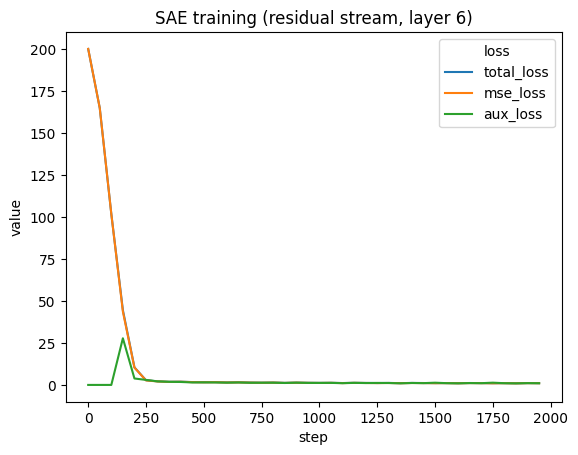

In [12]:
sns.lineplot(
    data=logs.melt(["step"], var_name="loss"),
    x="step",
    y="value",
    hue="loss",
)
plt.title(f"SAE training (residual stream, layer {LAYER})")
plt.show()

With the SAE trained, we run it in inference mode over every token in our corpus. The result is a sparse matrix `H` of shape `(num_tokens, h_dim)` — each row is the sparse representation of a single token's residual stream activation.

In [13]:
H = infer_sparse(X.clone(), sae, device=DEVICE)
print(f"H shape: {H.shape}")
print(f"Dead features (never fire): {(H.sum(dim=0) == 0).sum().item()} / {H.shape[1]}")

H shape: torch.Size([64000, 1536])
Dead features (never fire): 203 / 1536


## Exploring features

Lecture 10 looked at which *documents* activated each feature. Here, each row of `H` corresponds to a single **token**, so we can do something more fine-grained: find the exact token positions in the corpus where a feature fires most strongly, and print the surrounding context with the activating token highlighted.

The helper below does exactly that. Given a feature index, it finds the top-$k$ activating tokens across the whole corpus, then prints each one with a small context window around it. The activating token is wrapped in `>>...<<` so it's easy to spot.

In [14]:
def show_feature(feature_idx: int, k: int = 8, context: int = 10):
    act_col = H[:, feature_idx]
    top = torch.topk(act_col, k).indices.tolist()

    print(f"Feature {feature_idx} — top {k} activating tokens")
    print("-" * 60)
    for rank, flat_idx in enumerate(top, start=1):
        act = act_col[flat_idx].item()
        if act == 0:
            print(f"  [{rank}] (feature did not fire on any more tokens)")
            break

        doc = doc_indices[flat_idx].item()
        pos = tok_indices[flat_idx].item()
        ids = enc.input_ids[doc].tolist()
        real_len = enc.attention_mask[doc].sum().item()

        start = max(0, pos - context)
        end = min(real_len, pos + context + 1)

        before = tokenizer.decode(ids[start:pos])
        center = tokenizer.decode([ids[pos]])
        after = tokenizer.decode(ids[pos + 1 : end])

        print(f"  [{rank}] act={act:+.2f}  {before}>>{center}<<{after}")

Let's look at a few features to get a sense of what's in there. Run the cell below, and then keep running it with different feature indices. You'll probably see:

- Some features that fire on a specific token or a small cluster of related tokens
- Some that track syntactic position (end of a sentence, start of a quote, after a preposition, etc.)
- Some that seem to respond to a topic or situation spanning several tokens
- Some that look like total nonsense — the SAE is small and undertrained; not every feature will be interpretable

In [15]:
show_feature(0)

Feature 0 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+54.54   time there was a car. The car was slow>> and<< it made the driver feel sad. The driver said
  [2] act=+53.58   each side of the rug. The boy was slow>> and<<
  [3] act=+52.36  . Someone did not like it. He was small>> and<< mean. He was always mean to the truck.
  [4] act=+51.15  One day it was raining. The rain was cold>> and<< wet. A little girl named Grace was looking out
  [5] act=+50.37   Timmy had a special sack. It was thin>> and<< brown, but it was filled with lots of special
  [6] act=+49.17   was all closed up, and it just looked sad>> and<< boring.

The little lock was very fragile
  [7] act=+49.08   a shiny trophy in the grass. It was thin>> and<< had a picture of a soccer ball on it.
  [8] act=+48.94   there was a rich fireman. He was strong>> and<< brave. One day he had to save a cat


In [16]:
show_feature(1)

Feature 1 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+28.41   the ground and decided to grab it. She sat>> on<< it happily, not knowing what it was.
  [2] act=+28.00   and how the birds sang. She liked to sit>> on<< the window and feel the warm sun on her face
  [3] act=+27.42   queen went to the park to relax. She sat>> on<< a soft, green grass
  [4] act=+26.15   goes first. She climbs up the steps and sits>> on<< the slide. She slides down fast and laughs.
  [5] act=+25.78   high for her. She felt uncomfortable when she sat>> on<< the
  [6] act=+25.05   playing in her yard when she saw a patient sitting>> on<< the grass. The patient was crying and seemed very
  [7] act=+24.98   the slide. They run to the bench and sit>> on<< it.

"Look, a bird!"
  [8] act=+24.44   went to the park and saw a little boy sitting>> on<< a bench, looking sad.

Lily


In [17]:
show_feature(5)

Feature 5 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+38.95  Would you like some more tea, Mia?" Ben>> asks<<, holding a cup.

"Yes,
  [2] act=+38.27  . "Mom, can I pick one?" he>> asked<<.

Mom nodded. "Yes," she
  [3] act=+37.76  

"What is in the box?" Anna>> asked<<.

"I don't know. It
  [4] act=+37.68  

"Can we go, Mom?" Tim>> asks<<.

"OK, but be careful and
  [5] act=+37.62  

"What do you have there?" Emma>> asked<<.

"Oh, just something I found
  [6] act=+37.52   telescope.

"What is this?" Anna>> asks<<.

"It is a thing to look
  [7] act=+37.49  

"Can we open the fridge?" Lily>> asked<< Ben.

"Yes, we can.
  [8] act=+37.31  .

"Can I see it?" Ben>> asks<<.

"No, it is mine!"


## Task: browse and make sense of features

Now the fun part. Call `show_feature` on different feature indices (anywhere from 0 up to `H.shape[1] - 1`) and see what you can find. For each feature you look at, ask yourself: **what do the top-activating tokens have in common?** Can you describe the feature in a short English phrase? If not, is it close to something describable, or is it genuinely uninterpretable?

Some specific things to hunt for:

1. A feature that fires on a specific **word** (e.g. a character name, a common noun, a color).
2. A feature that fires on a **punctuation or syntactic position** (e.g. end-of-sentence, start of a quoted line, after a name).
3. A feature that responds to a **topic or situation** rather than a specific token.
4. A feature that you genuinely cannot interpret. What makes it hard?
5. A feature that seems to fire on one thing but has surprising exceptions.

Keep a quick note of what you find — feature index plus your best guess at what it represents. It helps to start with low indices (0–50) and skip around.

In [18]:
# YOUR EXPLORATION HERE — call show_feature with different indices.
show_feature(100)

Feature 100 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+17.27  Ben likes to>> play<< with his toy cars. He has many cars of
  [2] act=+17.03  Jill likes>> to<< skip. She skips to school, she sk
  [3] act=+16.99  Sara likes>> to<< sing. She sings in the morning, in the
  [4] act=+16.99  Sara likes>> to<< read books. She has many books in her room
  [5] act=+16.99  Sara likes>> to<< play with her dolls. She has many dolls with
  [6] act=+16.90  Sara likes to>> play<< with her dolls. She has many dolls with different
  [7] act=+15.48  John>> ran<< quickly to the mall. As he looked around,
  [8] act=+15.30  Molly was>> very<< excited because today was the day of her 3rd


In [19]:
# More space to explore.

### A few useful views of the feature space

Rather than picking indices at random, you can narrow your search. The cells below show:

- The **most active** features (the ones that fire on the most tokens). These are often shallow features tied to very common tokens.
- The **rarest active** features (those that fire on only a handful of tokens). These can be weirdly specific — they often capture narrow, interesting patterns.

Try `show_feature` on a few indices from each list and compare.

In [20]:
fire_counts = (H > 0).sum(dim=0)

most_active = torch.topk(fire_counts, 10).indices.tolist()
print("Most active features (feature_idx, fire_count):")
for f in most_active:
    print(f"  {f:>4d}  fires on {fire_counts[f].item()} tokens")

Most active features (feature_idx, fire_count):
   604  fires on 50329 tokens
   530  fires on 42044 tokens
  1034  fires on 29304 tokens
  1105  fires on 25554 tokens
   769  fires on 24373 tokens
   291  fires on 24045 tokens
  1239  fires on 17126 tokens
   441  fires on 14210 tokens
   201  fires on 13766 tokens
   707  fires on 13523 tokens


In [21]:
alive = torch.where(fire_counts > 0)[0]
rarest = alive[torch.argsort(fire_counts[alive])][:10].tolist()
print("Rarest active features:")
for f in rarest:
    print(f"  {f:>4d}  fires on {fire_counts[f].item()} tokens")

Rarest active features:
   482  fires on 1 tokens
   276  fires on 1 tokens
   994  fires on 1 tokens
  1462  fires on 1 tokens
   900  fires on 1 tokens
   285  fires on 1 tokens
  1402  fires on 1 tokens
  1128  fires on 1 tokens
   360  fires on 1 tokens
  1357  fires on 1 tokens


In [22]:
# Try a feature from each list.
show_feature(most_active[0])

Feature 604 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+77.38   their favorite was the beans.

When they>> arrived<< in the park, they spread out their blanket and
  [2] act=+76.38   hurt, so she started to cry.

>>Suddenly<<
  [3] act=+75.95   He slides down too and smiles.

They>> see<< a man with a big pink
  [4] act=+75.71   couldn't figure out where it was.

>>Suddenly<<, she had an
  [5] act=+75.57   the fun they would have.

When they>> arrived<< at their destination, their eyes lit up. They
  [6] act=+75.42   be careful," Anna said.

They ran>> to<<
  [7] act=+75.34  . He was having lots of fun.

>>Suddenly<<,
  [8] act=+74.55   the kite to grab it. 

>>Suddenly<<, a tough foot stepped on the


In [23]:
show_feature(rarest[0])

Feature 482 — top 8 activating tokens
------------------------------------------------------------
  [1] act=+6.16   secret hidden in the woods and he wanted to find>> it<<!

So Jim
  [2] (feature did not fire on any more tokens)


## Steering with SAE features

Once we've identified a feature, we can do something more than observe it — we can *intervene*. Each feature $f$ has a corresponding column of the decoder weight matrix, `sae.decoder.weight[:, f]`. This is the direction in residual-stream space that the SAE adds back whenever feature $f$ fires. Adding extra amounts of this direction during a forward pass is a crude but surprisingly effective way to **steer** the model's generation.

The recipe:

1. Pick a feature $f$ and a strength $\alpha$.
2. Register a forward hook on the same layer we trained the SAE on.
3. Inside the hook, add $\alpha \cdot W_{\text{dec}}[:, f]$ to the block's output.
4. Call `model.generate(...)` and see what comes out.

No retraining, no fine-tuning — just a one-line modification to the forward pass.

In [ ]:
def generate_with_steering(prompt, feature_idx=None, alpha=0.0, max_new_tokens=50, seed=0):
    """Generate text from `prompt`. If feature_idx is given, add alpha * W_dec[:, feature_idx]
    to the residual stream at LAYER on every forward pass during generation."""
    direction = sae.decoder.weight[:, feature_idx].detach().to(DEVICE) if feature_idx is not None else None

    def steer_hook(module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        hidden = hidden + alpha * direction
        return (hidden,) + output[1:] if isinstance(output, tuple) else hidden

    handle = (
        model.transformer.h[LAYER].register_forward_hook(steer_hook)
        if feature_idx is not None
        else None
    )

    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    torch.manual_seed(seed)
    with torch.no_grad():
        out = model.generate(
            ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            pad_token_id=tokenizer.eos_token_id,
        )

    if handle is not None:
        handle.remove()

    return tokenizer.decode(out[0], skip_special_tokens=True)

Let's compare an unsteered generation to a steered one. Pick a feature whose meaning you think you understand from the exploration above, plug it into `FEATURE`, and try a moderate value of `ALPHA`. Typical feature activations in our SAE are in the tens, so steering values in roughly that range tend to be noticeable without destroying the generation entirely.

We seed both runs identically, so any difference you see is purely the effect of the steering vector.

In [ ]:
PROMPT = "Once upon a time"
FEATURE = 5      # replace with a feature you identified above
ALPHA = 10.0

print("Unsteered:")
print(generate_with_steering(PROMPT))
print()
print(f"Steered (feature {FEATURE}, alpha={ALPHA}):")
print(generate_with_steering(PROMPT, feature_idx=FEATURE, alpha=ALPHA))

Sweeping $\alpha$ is often the most informative way to see what a feature is doing. At small values the effect is subtle; at larger values it dominates; eventually the generation breaks down into nonsense as we push the residual stream too far out of distribution.

In [ ]:
for alpha in [0, 2, 5, 10, 20, 50]:
    out = generate_with_steering(PROMPT, feature_idx=FEATURE, alpha=alpha)
    print(f"alpha={alpha:>3}: {out}")
    print()

### Your turn

Try a few different features. Some things worth investigating:

1. Take a feature that looked *interpretable* during exploration (e.g. a word-level feature, a topic feature). Does steering push the generation in the direction you'd expect?
2. Take a feature that looked *uninterpretable*. Does steering it produce any visible effect at all?
3. Try **negative** $\alpha$ — what happens when you subtract the feature direction?
4. Try steering features from different layers (you'll need to re-train the SAE at that layer first). Do early-layer features steer differently than late-layer ones?

In [ ]:
# YOUR STEERING EXPERIMENTS HERE.
generate_with_steering("The little girl", feature_idx=5, alpha=15.0)

## Reflection

A few things to think about as you wrap up:

- How clean were the features, overall? Did most of them have an interpretable pattern, or only some?
- Were the "most active" features more interpretable than the "rarest" ones, or the other way around?
- Which features were easiest to *steer*, and which resisted? Did ease of steering match your sense of how interpretable a feature was?
- If you have time, re-run the hook + SAE training on a **different layer** (try an early one like `LAYER = 2` and a late one like `LAYER = 10`). Do the features look qualitatively different? How?
- What do you think would change if we used 10x more stories? 10x the expansion factor? A larger $k$?